# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.beliefs import _get_current_beliefs, _get_pref_belief_gap
from eci.voting_system.decisions import _compute_option_preferences, _sample_choice

# Intialise environement

In [2]:
# Initialise environement
env = Environment(num_voters=1, num_candidates=2, num_preferences=2)

# Get and Change preference

In [3]:
# Get the preference for one agent (preference = (mean,precision)).
env.voters[0].preferences["mean"]
env.voters[0].preferences["precision"]

Array([0.74241656, 0.6436357 ], dtype=float32)

In [4]:
# Modify the preference.
env.voters[0].preferences["mean"] = jnp.array([0, 0])
env.voters[0].preferences["precision"] = jnp.array([0.1, 0.1])
env.voters[0]

Voter(id=-1, preferences={'mean': Array([0, 0], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, tonic_volatility=-1.9990893316548026, budget=100.0, perceived_outcome=None, vote_round_1=[], vote_round_2=[], softmax_probs_1=[], softmax_probs_2=[], dissatisfactions=[], trajectory=None, observation=None)

In [5]:
# Modify candidate policy.
env.candidates[0].policy["mean"] = jnp.array([1, 1])
env.candidates[0].policy["precision"] = jnp.array([0.1, 0.1])
env.candidates[1].policy["mean"] = jnp.array([3, 3])
env.candidates[1].policy["precision"] = jnp.array([0.1, 0.1])
env.candidates

[Candidate(id=0, policy={'mean': Array([1, 1], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, vote_count=0),
 Candidate(id=1, policy={'mean': Array([3, 3], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, vote_count=0)]

# Run observation

In [6]:
# Initialise the network.
env.initialize_network()

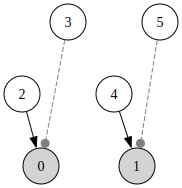

In [7]:
env.network.plot_network()

# Get the data from the observation

In [8]:
# Get the data for all agents.
all_agent_data = _get_current_beliefs(env)
all_agent_data

{0: {'means_belief': Array([0.89683163, 0.9739648 ], dtype=float32),
  'precisions_belief': Array([4.7281733, 4.707463 ], dtype=float32),
  'means_preference': Array([0, 0], dtype=int32),
  'precision_preference': Array([0.1, 0.1], dtype=float32),
  'mean_policy': Array([[1, 1],
         [3, 3]], dtype=int32),
  'precision_policy': Array([[0.1, 0.1],
         [0.1, 0.1]], dtype=float32)}}

# Visualise preference

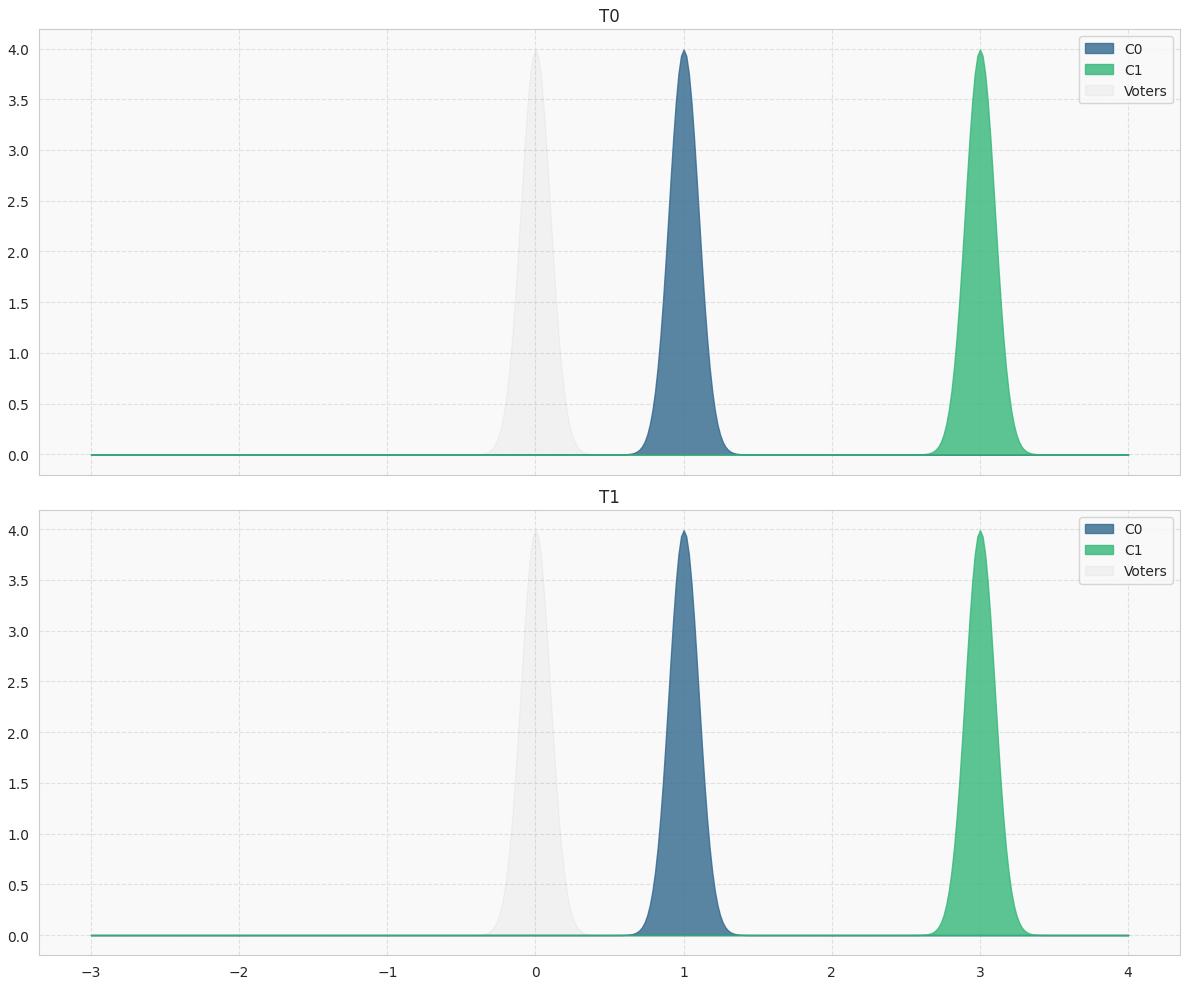

In [9]:
# Prepare simulation
viz = SimulationVisualizer()
adapter = SimulationAdapter()
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)

# Get the gap between belief and preference

In [10]:
# Get the disatisfaction of agent.
pref_belief_gap = _get_pref_belief_gap(all_agent_data)
pref_belief_gap

Array([2.9627714], dtype=float32)

# Compute the preference

In [11]:
# Compute preferences.
candidate_preferences = _compute_option_preferences(
    env,
    jnp.stack(
        [agent_data["means_preference"] for agent_data in all_agent_data.values()]
    ),
    jnp.stack(
        [agent_data["precision_preference"] for agent_data in all_agent_data.values()]
    ),
    pref_belief_gap,
)
candidate_preferences

Array([[2.8627715, 2.0627713]], dtype=float32)

# Vote 

In [24]:
# Do one vote.

key = jax.random.PRNGKey(int(time.time()))
key_round_1, key_round_2 = jax.random.split(key)
mask_round_1 = jnp.ones_like(candidate_preferences, dtype=bool)
masked_preferences = jnp.where(mask_round_1, candidate_preferences, -jnp.inf)
# Sample round 1 vote
vote_1, softmax_probs_1 = _sample_choice(key_round_1, masked_preferences)
vote_1

Array([1], dtype=int32)

In [14]:
# Do multiple vote for the same agent.
key = jax.random.PRNGKey(int(time.time()))
list_vote = []
num_votes = 100

for i in range(num_votes):
    key, key_iteration = jax.random.split(key)
    key_round_1, key_round_2 = jax.random.split(key_iteration)
    mask_round_1 = jnp.ones_like(candidate_preferences, dtype=bool)
    masked_preferences = jnp.where(mask_round_1, candidate_preferences, -jnp.inf)
    vote_1, softmax_probs_1 = _sample_choice(key_round_1, masked_preferences)
    list_vote.append(vote_1)

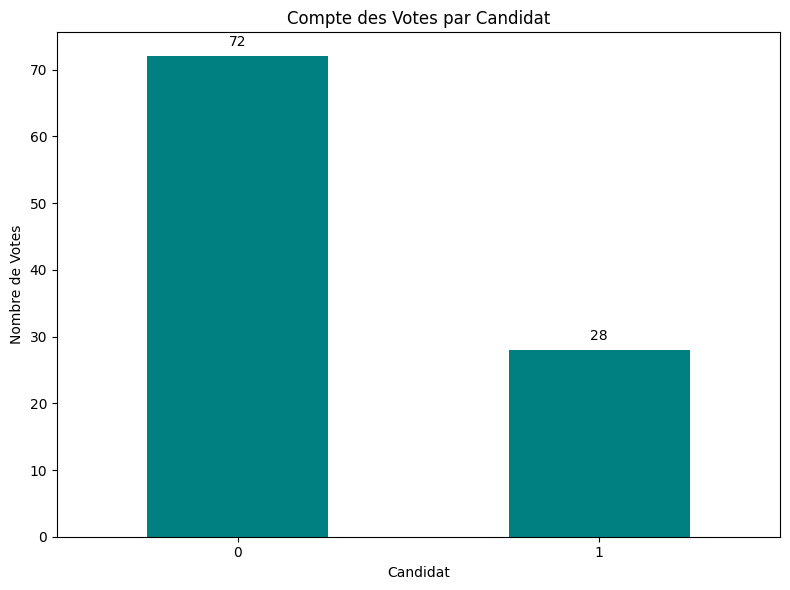

In [15]:
# Plot the votes.
df_votes = pd.DataFrame(list_vote, columns=["Candidat"])
vote_counts = df_votes["Candidat"].value_counts()
plt.figure(figsize=(8, 6))
ax = vote_counts.plot(kind="bar", color="teal")
plt.title("Compte des Votes par Candidat")
plt.ylabel("Nombre de Votes")
plt.xlabel("Candidat")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=5)
plt.tight_layout()
plt.savefig("vote_counts_bar_plot.png")